In [5]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


In [47]:
source = '/cosma5/data/durham/dc-pick2/simulations/Hyades'
orbit_path = source + '/orbit.csv'

snapshots = [0, 60, 120, 180, 240]

Myr_per_Nbody = 0.36627254517014160E+03/ 0.15200000000000000E+03


In [44]:
df = pd.read_csv(orbit_path)

df['RG'] = np.sqrt(df['RGx']**2 + df['RGy']**2 + df['RGz']**2)

df

,T,RGx,RGy,RGz,VGx,VGy,VGz,JZ,ET,RG
0,0.000000,-1.760000,11.370000,0.110000,143.300000,2.400000,0.700000,-288070.060398,0.000000,11.505938
1,4.819376,-1.048345,11.341873,0.098368,145.309362,-13.864964,-5.384619,-288070.060398,-0.000944,11.390644
2,9.638751,-0.329208,11.232785,0.058226,146.319102,-30.454904,-10.634601,-288070.060398,0.794992,11.237759
3,14.458127,0.392300,11.041109,-0.001652,146.267898,-47.375080,-12.922355,-288070.060398,3.629713,11.048076
4,19.277502,1.110784,10.765321,-0.060729,145.078719,-64.572506,-10.268684,-288070.060398,8.714572,10.822646
...,...,...,...,...,...,...,...,...,...,...
126,607.241325,-0.731962,10.563830,0.049973,157.658347,-43.623777,11.270696,-288070.060398,109.405560,10.589276
127,612.060700,0.047089,10.304175,0.092150,158.249858,-61.814856,5.385190,-288070.060398,108.079036,10.304694
128,616.880076,0.825689,9.953776,0.100283,157.440477,-80.439213,-2.224171,-288070.060398,106.726712,9.988467
129,621.699452,1.596557,9.510521,0.070242,155.062343,-99.477372,-9.780530,-288070.060398,103.553842,9.643855


In [ ]:
for i, snap in enumerate(snapshots):
    path = source + f'/snap.40_{snap}.h5part'
    
    with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]
        x = f[last_step]['X1'][:]
        y = f[last_step]['X2'][:]
        z = f[last_step]['X3'][:]
        m = f[last_step]['M'][:]
        t = f[last_step].attrs['Time'] * Myr_per_Nbody

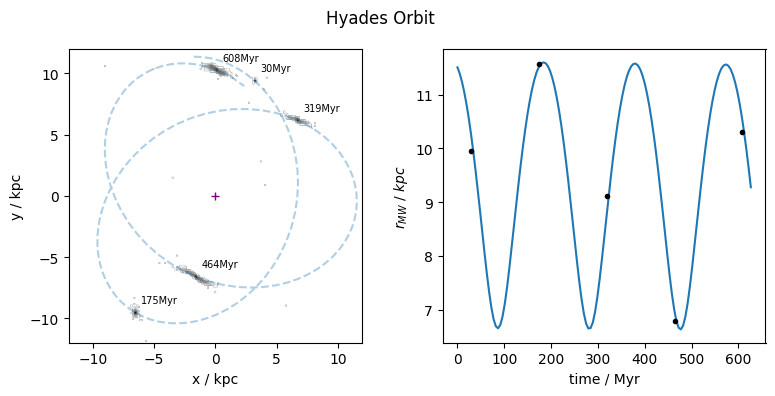

In [138]:
xmin, xmax = -12, 12
ymin, ymax = -12, 12

zoom = 250

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

snap_times = []
snap_idx = []

density = np.zeros((bins, bins))
for i, snap in enumerate(snapshots):
    path = source + f'/snap.40_{snap}.h5part'

    with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]

        x = f[last_step]['X1'][:] / zoom
        y = f[last_step]['X2'][:] / zoom
        t = f[last_step].attrs['Time'] * Myr_per_Nbody
        snap_times.append(t)

        com_x = np.median(x)
        com_y = np.median(y)
    
        idx = np.searchsorted(df['T'], t)
        galx = df['RGx'][idx]
        galy = df['RGy'][idx]

    hist, _, _ = np.histogram2d(x - com_x + galx, y - com_y + galy,
                                bins=200, 
                                range=[[xmin, xmax],
                                       [ymin, ymax]])

    density += hist

    ax[0].text(galx + 0.5, galy + 0.75, f"{t:.0f}Myr", fontsize=7)
    
    ax[1].plot(t,df['RG'][idx], marker='.', color='black', zorder=10)


ax[0].imshow(density.T, origin='lower', 
             extent=[xmin, xmax, ymin, ymax],
             cmap='gray_r', norm=LogNorm()
)

ax[0].plot(df['RGx'], df['RGy'], linestyle='dashed', alpha=0.35, color='tab:blue')
ax[0].plot(0, 0, marker='+', color='purple', linestyle='')


ax[0].set_xlim([xmin, xmax])
ax[0].set_ylim([ymin, ymax])
ax[0].set_aspect('equal')
ax[0].set_xlabel("x / kpc")
ax[0].set_ylabel("y / kpc")

ax[1].plot(df['T'], df['RG'],  color='tab:blue')
ax[1].set_xlabel('time / Myr')
ax[1].set_ylabel(r'$r_{MW}\ /\ kpc$')

plt.suptitle('Hyades Orbit')
plt.tight_layout()
plt.show()